In [1]:
import pandas as pd

In [2]:
df_inv_item=pd.read_csv('Inventory_items.csv')

In [3]:
df_inv_item

,id,product_id,product_distribution_center_id,creation_date,creation_time,sold_date,sold_time,product_cost,product_retail_price,product_category,product_date,product_brand,product_department
0,174571,13844,7,2025-08-11,08:46:52,2025-09-18,04:50:52,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
1,174572,13844,7,2024-07-16,03:08:00,NaN,NaN,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
2,216419,13844,7,2023-09-04,19:33:12,2023-09-21,04:02:12,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
3,216420,13844,7,2024-02-16,00:15:00,NaN,NaN,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
4,216421,13844,7,2021-11-05,16:11:00,NaN,NaN,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
...,...,...,...,...,...,...,...,...,...,...,...,...,...
489818,332010,25590,3,2020-11-05,04:42:00,NaN,NaN,10.39,24.00,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,Men
489819,467577,25590,3,2026-01-12,04:57:04,2026-02-10,15:08:04,10.39,24.00,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,Men
489820,467578,25590,3,2024-07-07,15:52:00,NaN,NaN,10.39,24.00,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,Men
489821,467579,25590,3,2024-03-21,16:36:00,NaN,NaN,10.39,24.00,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,Men


In [4]:
df_inv_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489823 entries, 0 to 489822
Data columns (total 13 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              489823 non-null  int64  
 1   product_id                      489823 non-null  int64  
 2   product_distribution_center_id  489823 non-null  int64  
 3   creation_date                   489823 non-null  object 
 4   creation_time                   489823 non-null  object 
 5   sold_date                       181404 non-null  object 
 6   sold_time                       181404 non-null  object 
 7   product_cost                    489823 non-null  float64
 8   product_retail_price            489823 non-null  float64
 9   product_category                489823 non-null  object 
 10  product_date                    489782 non-null  object 
 11  product_brand                   489411 non-null  object 
 12  product_departme

In [5]:
df_check = df_inv_item[['product_id', 'creation_date','sold_date']]
df_check

,product_id,creation_date,sold_date
0,13844,2025-08-11,2025-09-18
1,13844,2024-07-16,NaN
2,13844,2023-09-04,2023-09-21
3,13844,2024-02-16,NaN
4,13844,2021-11-05,NaN
...,...,...,...
489818,25590,2020-11-05,NaN
489819,25590,2026-01-12,2026-02-10
489820,25590,2024-07-07,NaN
489821,25590,2024-03-21,NaN


In [6]:
df_check['creation_date'] = pd.to_datetime(df_check['creation_date'], errors='coerce')
df_check['sold_date'] = pd.to_datetime(df_check['sold_date'], errors='coerce')

C:\Users\matte\AppData\Local\Temp\ipykernel_16876\3758163726.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_check['creation_date'] = pd.to_datetime(df_check['creation_date'], errors='coerce')
C:\Users\matte\AppData\Local\Temp\ipykernel_16876\3758163726.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_check['sold_date'] = pd.to_datetime(df_check['sold_date'], errors='coerce')


In [7]:
anomalie = []
for idx in df_check.index:
    if df_check.loc[idx, 'creation_date'] > df_check.loc[idx, 'sold_date']:
        anomalie.append(df_check.loc[idx, 'product_id'])
if len (anomalie)==0:
    print('non ci sono anomalie')
else:
         print('I prodotti con anomalie temporali sono:', anomalie)


non ci sono anomalie


In [8]:
anomalie_prezzi = []
for idx in df_inv_item.index:
    if df_inv_item.loc[idx, 'product_retail_price'] <= 0:
        anomalie_prezzi.append(df_inv_item.loc[idx, 'product_id'])

if len(anomalie_prezzi) == 0:
    print('Non ci sono anomalie sui prezzi')
else:
    print('I prodotti con anomalie sui prezzi sono:', anomalie_prezzi)

Non ci sono anomalie sui prezzi


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

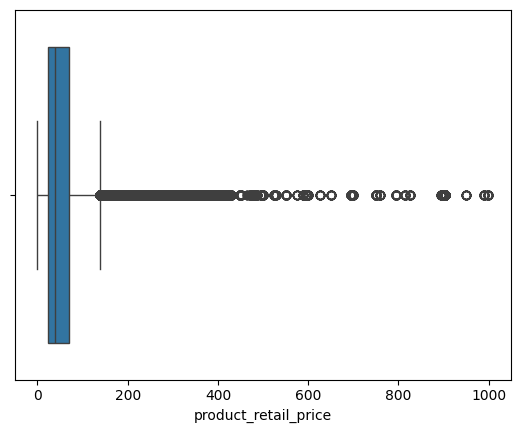

In [10]:
sns.boxplot(x='product_retail_price', data=df_inv_item)
plt.show()

In [11]:
df_inv_item = df_inv_item.rename(columns={'product_date': 'product_name'})

In [12]:
df_inv_item['product_retail_price'].sort_values(ascending=False)

210537    999.00
210538    999.00
210539    999.00
210540    999.00
210541    999.00
           ...  
10421       0.02
10423       0.02
10422       0.02
10425       0.02
10424       0.02
Name: product_retail_price, Length: 489823, dtype: float64

In [13]:
df_inv_item[['product_name', 'product_category', 'product_retail_price']].sort_values(by='product_retail_price', ascending=False).head(10)

,product_name,product_category,product_retail_price
210537,Darla,Outerwear & Coats,999.0
210538,Darla,Outerwear & Coats,999.0
210539,Darla,Outerwear & Coats,999.0
210540,Darla,Outerwear & Coats,999.0
210541,Darla,Outerwear & Coats,999.0
210542,Darla,Outerwear & Coats,999.0
210530,Darla,Outerwear & Coats,999.0
210531,Darla,Outerwear & Coats,999.0
210532,Darla,Outerwear & Coats,999.0
210533,Darla,Outerwear & Coats,999.0


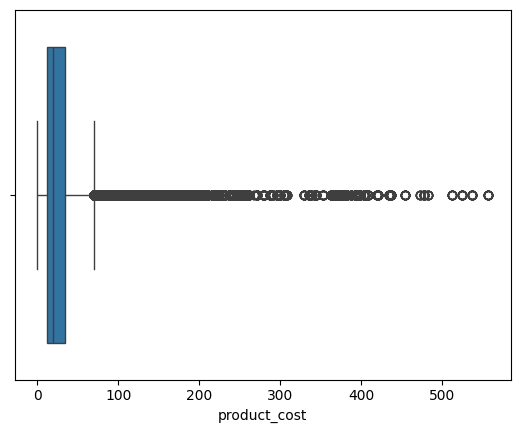

In [14]:
sns.boxplot(x='product_cost', data=df_inv_item)
plt.show()

In [15]:
df_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489823 entries, 0 to 489822
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   product_id     489823 non-null  int64         
 1   creation_date  489823 non-null  datetime64[ns]
 2   sold_date      181404 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1)
memory usage: 11.2 MB


In [16]:
df_inv_item['product_category'].unique()

array(['Accessories', 'Active', 'Blazers & Jackets', 'Clothing Sets',
       'Dresses', 'Fashion Hoodies & Sweatshirts', 'Intimates', 'Jeans',
       'Jumpsuits & Rompers', 'Leggings', 'Maternity',
       'Outerwear & Coats', 'Pants', 'Pants & Capris', 'Plus', 'Shorts',
       'Skirts', 'Sleep & Lounge', 'Socks', 'Socks & Hosiery', 'Suits',
       'Suits & Sport Coats', 'Sweaters', 'Swim', 'Tops & Tees',
       'Underwear'], dtype=object)

In [17]:
categorie=[df_inv_item['product_category'].unique]

In [18]:
outliers = []

for cat in categorie:
    df_cat = df_inv_item[df_inv_item['product_category'] == cat]
    Q1 = df_cat['product_retail_price'].quantile(0.25)
    Q3 = df_cat['product_retail_price'].quantile(0.75)
    IQR = Q3 - Q1
    limite_alto = Q3 + 1.5 * IQR
    limite_basso = Q1 - 1.5 * IQR
    out_cat = df_cat[(df_cat['product_retail_price'] > limite_alto) | 
                     (df_cat['product_retail_price'] < limite_basso)]
    outliers.append(out_cat)

df_outliers_price = pd.concat(outliers)
df_outliers_price





,id,product_id,product_distribution_center_id,creation_date,creation_time,sold_date,sold_time,product_cost,product_retail_price,product_category,product_name,product_brand,product_department


In [19]:
outliers_cost = []

for cat in categorie:
    df_cat = df_inv_item[df_inv_item['product_category'] == cat]
    Q1 = df_cat['product_cost'].quantile(0.25)
    Q3 = df_cat['product_cost'].quantile(0.75)
    IQR = Q3 - Q1
    limite_alto = Q3 + 1.5 * IQR
    limite_basso = Q1 - 1.5 * IQR
    
    # Outlier sia alti che bassi
    out_cat = df_cat[(df_cat['product_cost'] > limite_alto) | 
                     (df_cat['product_cost'] < limite_basso)]
    outliers_cost.append(out_cat)

df_outliers_cost = pd.concat(outliers_cost)
df_outliers_cost

,id,product_id,product_distribution_center_id,creation_date,creation_time,sold_date,sold_time,product_cost,product_retail_price,product_category,product_name,product_brand,product_department


In [20]:
stats_per_categoria = df_inv_item.groupby('product_category')['product_retail_price'].describe()
stats_per_categoria

,count,mean,std,min,25%,50%,75%,max
product_category,,,,,,,,
Accessories,26684.0,42.992308,49.310619,0.02,12.99,24.44,49.00,299.00
Active,24579.0,50.689686,75.555596,1.95,22.00,34.00,55.00,903.00
Blazers & Jackets,8372.0,91.252979,90.614162,7.68,18.90,59.99,130.00,698.00
Clothing Sets,532.0,86.890282,43.317702,19.99,57.99,70.00,109.99,199.95
Dresses,14510.0,85.754567,84.332248,7.99,32.99,59.00,108.00,498.00
Fashion Hoodies & Sweatshirts,32017.0,54.457790,37.134630,8.88,34.99,49.95,64.99,903.00
Intimates,36128.0,33.499960,28.509458,1.75,16.31,27.99,42.00,903.00
Jeans,34956.0,98.456888,63.406773,9.99,46.07,79.00,142.95,389.00
Jumpsuits & Rompers,2474.0,41.891653,58.025310,8.74,12.23,23.00,47.99,550.00


In [21]:
outerwear = df_inv_item[df_inv_item['product_category'] == 'Outerwear & Coats']
print(f"\nPrezzi = 999.00€: {len(outerwear[outerwear['product_retail_price'] == 999])}")
print(f"Prezzi >= 500€: {len(outerwear[outerwear['product_retail_price'] >= 500])}")
print(f"Prezzi < 20€: {len(outerwear[outerwear['product_retail_price'] < 20])}")


Prezzi = 999.00€: 26
Prezzi >= 500€: 751
Prezzi < 20€: 316


In [22]:
prodotti_prezzobasso= outerwear[outerwear['product_retail_price'] < 20]
prodotti_prezzobasso['product_name'].unique()

array(["Alki'i Mens 1/4-Zip Lightweight Performance Micro Fleece Pullover jacket",
       'Allegra K Embossed Double Breasted Royal Blue Poncho Coat for Lady M',
       'Allegra K Ladies Leopard Print Buttonless Long Sleeve Coat Outwear Black Brown S',
       'Allegra K Ladies Long Sleeve Turtle Neck Double Breasted Coat Off White XS',
       'Allegra K Ladies Round Neck Split Side Cutting Two Button Up Front Coat Army Green S',
       'Allegra K Woman Light Gray Hooded Long Sleeve Plush Winter Coat S',
       'Allegra K Women Pink Long Sleeve Slit Pockets Toggle Coat Jacket XS',
       'Cotton Traders Quarter Zip Pocketed Fleece',
       "Harriton Women's 8 oz Full-Zip Fleece Jacket M990W",
       "IWB By Blac Label Men's Hunting Puffer Jacket Vest Polo",
       'LAST KISS OmbrÃ© Wool-Blend Double Breasted Coat W/ Belt [987ILK20] BLW',
       'Mens Heavy Sherpa Fleece Lined Jacket',
       'Mens Polar Fleece Full Zip Jacket',
       'Mens Two Tone Heavy Sherpa Lined Fleece Hooded Jack

In [23]:
missing = df_inv_item.isnull().sum()
missing_pct = (missing / len(df_inv_item) * 100).round(2)

missing_df = pd.DataFrame({
    'Valori Nulli': missing,
    'Percentuale (%)': missing_pct
})

print("Valori mancanti per colonna:")
print(missing_df[missing_df['Valori Nulli'] > 0].sort_values('Valori Nulli', ascending=False))

Valori mancanti per colonna:
               Valori Nulli  Percentuale (%)
sold_date            308419            62.97
sold_time            308419            62.97
product_brand           412             0.08
product_name             41             0.01


In [24]:
df_prod=pd.read_csv('Products.csv')
df_prod

,id,category,name,brand,department,distribution_center_id,cost,retail_price
0,1,Tops & Tees,Seven7 Women's Long Sleeve Stripe Belted Top,Seven7,Women,1,27.05,49.00
1,2,Tops & Tees,Calvin Klein Women's MSY Crew Neck Roll Sleeve,Calvin Klein,Women,3,36.63,69.50
2,3,Tops & Tees,Calvin Klein Jeans Women's Solid Flyaway Shirt,Calvin Klein Jeans,Women,8,41.00,69.50
3,4,Tops & Tees,Bailey 44 Women's Undertow Top,Bailey 44,Women,6,57.13,108.00
4,5,Tops & Tees,Anne Klein Women's Plus-Size Button Front Blouse,Anne Klein,Women,2,52.36,94.00
...,...,...,...,...,...,...,...,...
29115,29116,Accessories,Ray-Ban RB 3217 Sunglasses- All Colors And SIZES,Ray-Ban,Men,2,36.02,101.76
29116,29117,Accessories,Tumi Monaco Slim Single Billfold,TUMI,Men,2,40.39,108.00
29117,29118,Accessories,Spy Optic Dirty Mo Wrap Sunglasses,SPY,Men,10,38.72,110.00
29118,29119,Accessories,Tumi Men's Alpha Gusseted Id Card Case,TUMI,Men,2,19.42,48.42


In [25]:
df_events=pd.read_csv('events.csv')
df_events

,id,user_id,city,state,browser,traffic_source,event_type,creation_date,order_time
0,193079,14759,São Paulo,São Paulo,Chrome,Adwords,cart,2022-10-07,08:35:50
1,157237,12062,São Paulo,São Paulo,Chrome,Adwords,cart,2025-08-13,15:35:03
2,1290688,99790,São Paulo,São Paulo,Safari,Adwords,cart,2023-10-04,18:17:26
3,234294,17942,São Paulo,São Paulo,Chrome,Adwords,cart,2024-04-30,06:15:27
4,1145403,88606,São Paulo,São Paulo,Firefox,Adwords,cart,2025-06-06,12:25:07
...,...,...,...,...,...,...,...,...,...
1293921,610734,46935,London,England,Chrome,YouTube,purchase,2022-08-13,22:52:13
1293922,1233354,95411,Sunderland,England,IE,YouTube,purchase,2025-08-18,09:19:26
1293923,1229153,95090,London,England,Chrome,YouTube,purchase,2026-01-13,23:22:44
1293924,552834,42491,Middlesbrough,England,Firefox,YouTube,purchase,2022-07-30,13:36:01


In [26]:
df_inv_item


,id,product_id,product_distribution_center_id,creation_date,creation_time,sold_date,sold_time,product_cost,product_retail_price,product_category,product_name,product_brand,product_department
0,174571,13844,7,2025-08-11,08:46:52,2025-09-18,04:50:52,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
1,174572,13844,7,2024-07-16,03:08:00,NaN,NaN,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
2,216419,13844,7,2023-09-04,19:33:12,2023-09-21,04:02:12,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
3,216420,13844,7,2024-02-16,00:15:00,NaN,NaN,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
4,216421,13844,7,2021-11-05,16:11:00,NaN,NaN,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
...,...,...,...,...,...,...,...,...,...,...,...,...,...
489818,332010,25590,3,2020-11-05,04:42:00,NaN,NaN,10.39,24.00,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,Men
489819,467577,25590,3,2026-01-12,04:57:04,2026-02-10,15:08:04,10.39,24.00,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,Men
489820,467578,25590,3,2024-07-07,15:52:00,NaN,NaN,10.39,24.00,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,Men
489821,467579,25590,3,2024-03-21,16:36:00,NaN,NaN,10.39,24.00,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,Men


In [27]:
df_inv_item['creation_date'] = pd.to_datetime(df_check['creation_date'], errors='coerce')
df_inv_item['sold_date'] = pd.to_datetime(df_check['sold_date'], errors='coerce')

In [28]:
df_inv_item.to_csv('inventory_items_clean.csv', index=False)

In [34]:
pattern = r"[\d*?!#]"

mask = (
    df_inv_item["product_name"].str.contains(pattern, na=False) |
    df_inv_item["product_category"].str.contains(pattern, na=False)
)

# mostra i risultati
risultati = df_inv_item[mask]


In [35]:
risultati

,id,product_id,product_distribution_center_id,creation_date,creation_time,sold_date,sold_time,product_cost,product_retail_price,product_category,product_name,product_brand,product_department
0,174571,13844,7,2025-08-11,08:46:52,2025-09-18,04:50:52,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
1,174572,13844,7,2024-07-16,03:08:00,NaT,NaN,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
2,216419,13844,7,2023-09-04,19:33:12,2023-09-21,04:02:12,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
3,216420,13844,7,2024-02-16,00:15:00,NaT,NaN,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
4,216421,13844,7,2021-11-05,16:11:00,NaT,NaN,2.77,6.99,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,Women
...,...,...,...,...,...,...,...,...,...,...,...,...,...
489459,419752,25815,2,2022-11-27,05:20:28,2023-01-07,13:29:28,6.39,12.99,Underwear,YogaColors Solid Color Light-Weight Fashionabl...,YogaColors,Men
489460,419753,25815,2,2024-06-18,12:45:00,NaT,NaN,6.39,12.99,Underwear,YogaColors Solid Color Light-Weight Fashionabl...,YogaColors,Men
489461,419754,25815,2,2024-10-05,03:49:00,NaT,NaN,6.39,12.99,Underwear,YogaColors Solid Color Light-Weight Fashionabl...,YogaColors,Men
489462,467529,25815,2,2024-05-10,15:12:14,2024-05-22,17:23:14,6.39,12.99,Underwear,YogaColors Solid Color Light-Weight Fashionabl...,YogaColors,Men


In [43]:
df_inv_item[df_inv_item['product_name']=='!it Jeans']

,id,product_id,product_distribution_center_id,creation_date,creation_time,sold_date,sold_time,product_cost,product_retail_price,product_category,product_name,product_brand,product_department
